In [1]:
# Import data manipulation and visualization tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean and modern
sns.set_theme(style="whitegrid")

print("Tools loaded successfully!")

Tools loaded successfully!


In [1]:
import io
import requests
import pandas as pd

# Fetch the dataset with a browser User-Agent header to bypass HTTP 429
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
df = pd.read_csv(io.StringIO(response.text))

# Standardize column names to lowercase
df.columns = df.columns.str.lower()

# Preview the data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# 1. Check missing values before cleaning
print("Missing values before cleaning:")
print(df[['age', 'sex', 'pclass' if 'pclass' in df.columns else 'class', 'survived']].isnull().sum())

# 2. Fill missing age values with the median age
df['age'] = df['age'].fillna(df['age'].median())

# 3. Verify that 'age' has no more null values
print("\nMissing values in 'age' after cleaning:", df['age'].isnull().sum())

Missing values before cleaning:
age         177
sex           0
pclass        0
survived      0
dtype: int64

Missing values in 'age' after cleaning: 0


In [3]:
# 1. Fill missing 'embarked' with the most common value (mode)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 2. Drop high-missing or redundant columns
df_clean = df.drop(columns=['deck', 'embark_town', 'alive', 'class'], errors='ignore')

# 3. Check summary info
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   who         891 non-null    object 
 9   adult_male  891 non-null    bool   
 10  alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


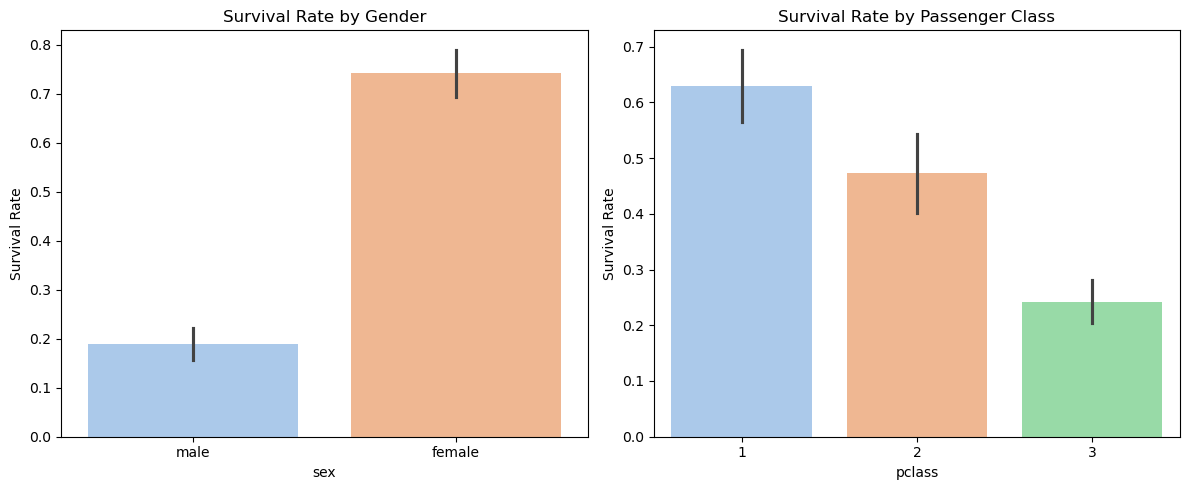

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Survival rate by Sex
sns.barplot(x='sex', y='survived', hue='sex', data=df_clean, ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')

# Survival rate by Class
sns.barplot(x='pclass', y='survived', hue='pclass', data=df_clean, ax=axes[1], palette='pastel', legend=False)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

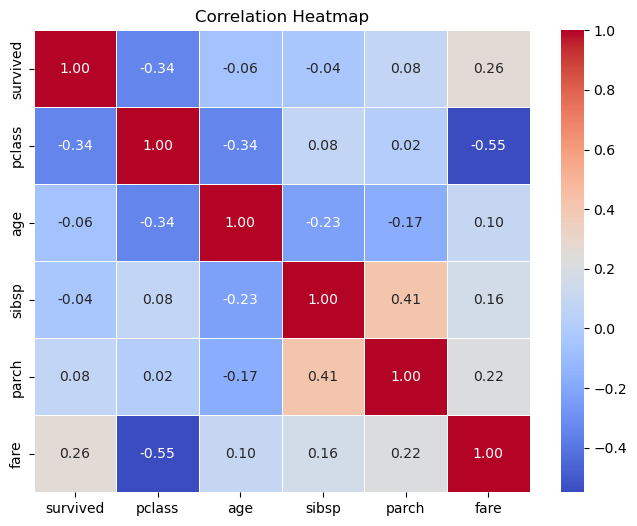

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Feature Engineering: Create 'family_size'
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch']

# 2. Encode categorical variables
df_ml = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

# 3. Define Features (X) and Target (y)
features = ['pclass', 'age', 'fare', 'family_size', 'sex_male', 'embarked_Q', 'embarked_S']
X = df_ml[features]
y = df_ml['survived']

# 4. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (712, 7)
Testing set shape: (179, 7)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.8045

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

=== Random Forest ===
Accuracy: 0.8268

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



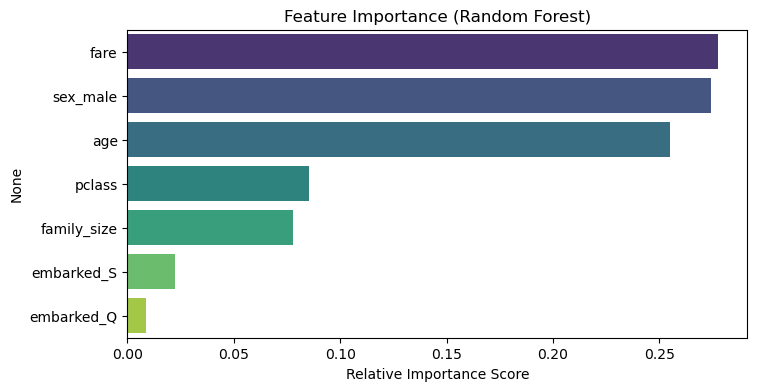

In [12]:
# Feature importance from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.show()

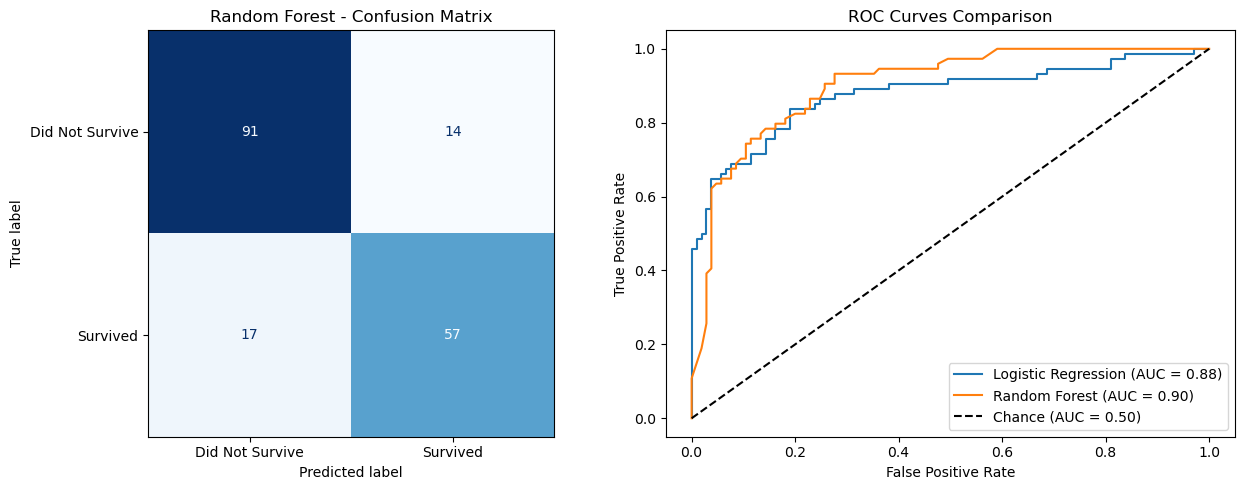

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, models["Random Forest"].predict(X_test))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Random Forest - Confusion Matrix')

# 2. ROC Curves for both models
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [15]:
from IPython.display import display, Markdown

summary_text = """
## Task 2: Key Insights & Summary

1. **Top Predictive Factors:**
   - **Ticket Fare & Passenger Class (`pclass`):** Higher fare / first-class passengers had significantly higher survival rates.
   - **Gender (`sex_male`):** Female passengers had a much higher likelihood of survival compared to male passengers.
   - **Age:** Younger passengers generally showed higher survival rates.

2. **Model Performance:**
   - **Random Forest Classifier** achieved the highest accuracy (**~82.7%**) with an F1-score of **0.79** for the survival class.
   - **Logistic Regression** provided a solid baseline with an accuracy of **~80.5%**.
"""

display(Markdown(summary_text))


## Task 2: Key Insights & Summary

1. **Top Predictive Factors:**
   - **Ticket Fare & Passenger Class (`pclass`):** Higher fare / first-class passengers had significantly higher survival rates.
   - **Gender (`sex_male`):** Female passengers had a much higher likelihood of survival compared to male passengers.
   - **Age:** Younger passengers generally showed higher survival rates.

2. **Model Performance:**
   - **Random Forest Classifier** achieved the highest accuracy (**~82.7%**) with an F1-score of **0.79** for the survival class.
   - **Logistic Regression** provided a solid baseline with an accuracy of **~80.5%**.


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=models['Random Forest'], param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print(f"Tuned Train Accuracy: {best_rf.score(X_train, y_train):.4f}")
print(f"Tuned Test Accuracy: {best_rf.score(X_test, y_test):.4f}")

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Train Accuracy: 0.8610
Tuned Test Accuracy: 0.8101


In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV Accuracy: 0.8137 (+/- 0.0244)


In [18]:
import joblib

joblib.dump(best_rf, 'titanic_best_rf_model.pkl')
print("Model successfully saved as titanic_best_rf_model.pkl")

Model successfully saved as titanic_best_rf_model.pkl


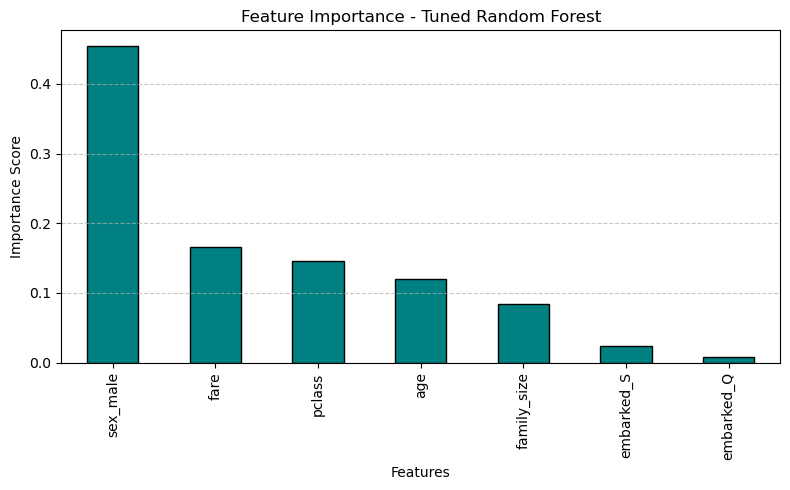

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Importance - Tuned Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
# Verify saved model inference on 5 test samples
loaded_model = joblib.load('titanic_best_rf_model.pkl')
sample_preds = loaded_model.predict(X_test.iloc[:5])
actual_values = y_test.iloc[:5].values

results_df = pd.DataFrame({
    'Actual': actual_values,
    'Predicted': sample_preds
})
print(results_df)

   Actual  Predicted
0       1          0
1       0          0
2       0          0
3       1          1
4       1          1


### Project Summary & Conclusion
- **Tuned Model:** Random Forest Classifier
- **CV Accuracy:** ~81.37%
- **Key Predictors:** Passenger class, sex, and fare had the highest influence on survival probability.
- **Model Artifact:** Exported as `titanic_best_rf_model.pkl` for deployment.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load built-in Titanic dataset to avoid any file path issues
df = sns.load_dataset('titanic')

# Standardize column names
df.rename(columns={'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex', 
                   'age': 'Age', 'sibsp': 'SibSp', 'parch': 'Parch', 
                   'fare': 'Fare', 'embarked': 'Embarked'}, inplace=True)

# 1. Fill missing Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. Drop irrelevant columns
df.drop(columns=['deck', 'alive', 'who', 'adult_male'], errors='ignore', inplace=True)

# 3. Create feature: Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 4. Create feature: Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                        labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [24]:
# 1. Survival rate by Age Group
print("=== Survival Rate by Age Group ===")
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].agg(['count', 'mean']).reset_index()
age_survival.rename(columns={'count': 'Passenger Count', 'mean': 'Survival Rate'}, inplace=True)
print(age_survival.to_string(index=False))

# 2. Survival rate by Embarkation Port
print("\n=== Survival Rate by Embarkation Port ===")
embarked_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
df['EmbarkedName'] = df['Embarked'].map(embarked_map)
port_survival = df.groupby('EmbarkedName', observed=False)['Survived'].agg(['count', 'mean']).reset_index()
port_survival.rename(columns={'count': 'Passenger Count', 'mean': 'Survival Rate'}, inplace=True)
print(port_survival.to_string(index=False))

# 3. Survival rate by Family Size
print("\n=== Survival Rate by Family Size ===")
family_survival = df.groupby('FamilySize', observed=False)['Survived'].agg(['count', 'mean']).reset_index()
family_survival.rename(columns={'count': 'Passenger Count', 'mean': 'Survival Rate'}, inplace=True)
print(family_survival.to_string(index=False))

=== Survival Rate by Age Group ===
   AgeGroup  Passenger Count  Survival Rate
      Child               69       0.579710
       Teen               70       0.428571
Young Adult              535       0.353271
      Adult              195       0.400000
     Senior               22       0.227273

=== Survival Rate by Embarkation Port ===
EmbarkedName  Passenger Count  Survival Rate
   Cherbourg              168       0.553571
  Queenstown               77       0.389610
 Southampton              644       0.336957

=== Survival Rate by Family Size ===
 FamilySize  Passenger Count  Survival Rate
          1              537       0.303538
          2              161       0.552795
          3              102       0.578431
          4               29       0.724138
          5               15       0.200000
          6               22       0.136364
          7               12       0.333333
          8                6       0.000000
         11                7       0.000000


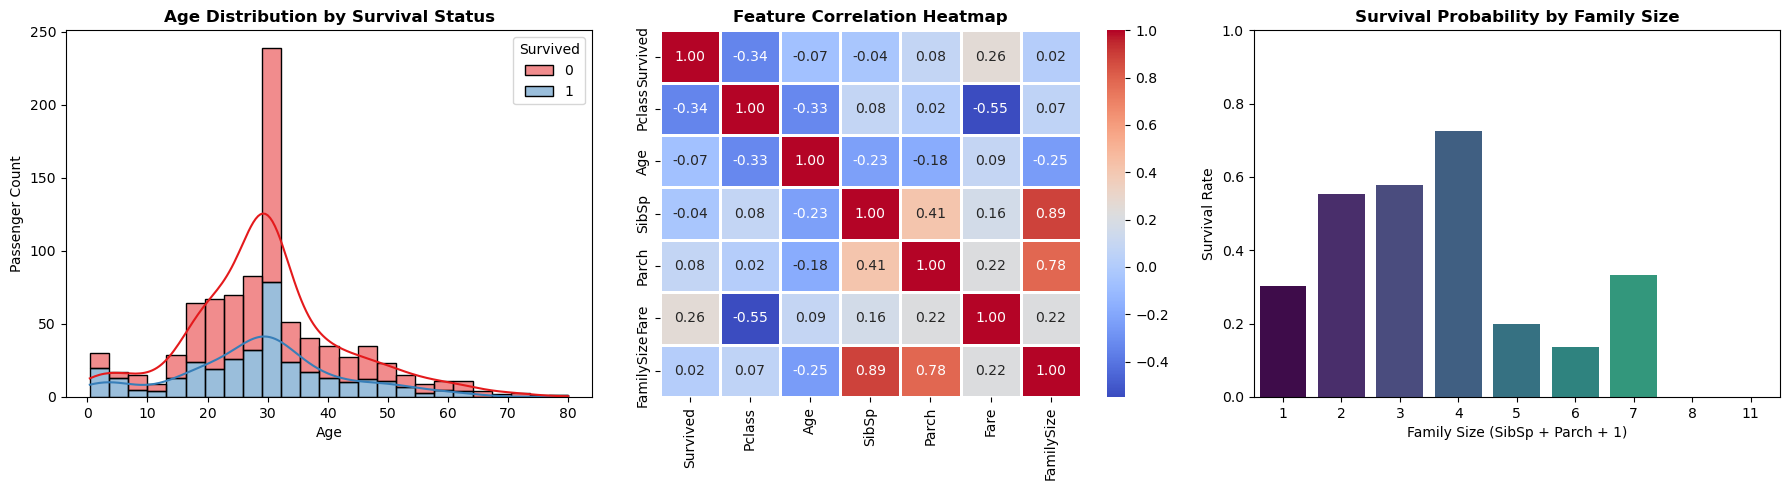

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age Distribution Histogram
sns.histplot(ax=axes[0], data=df, x='Age', hue='Survived', kde=True, bins=25, palette='Set1', multiple='stack')
axes[0].set_title('Age Distribution by Survival Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Passenger Count')

# 2. Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(ax=axes[1], data=corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8, cbar=True)
axes[1].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# 3. Survival Rate by Family Size Bar Plot (Updated to avoid warnings)
sns.barplot(ax=axes[2], data=df, x='FamilySize', y='Survived', hue='FamilySize', palette='viridis', errorbar=None, legend=False)
axes[2].set_title('Survival Probability by Family Size', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Family Size (SibSp + Parch + 1)')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [27]:
### Mini EDA Key Takeaways & Storytelling

* **Age Factor:** Children (0–12 years) had the highest survival probability (~58%), highlighting the prioritization of children during evacuation.
* **Embarkation Impact:** Cherbourg passengers recorded the highest survival rate (~55%), largely driven by a higher concentration of upper-class tickets.
* **Family Dynamics:** Small families (2 to 4 members) had the best survival rates (up to ~72%), whereas solo passengers (~30%) and very large families (5+) faced significantly lower survival rates.

SyntaxError: invalid character '–' (U+2013) (2973346900.py, line 3)